# CZ Gate Optimization with Neural Networks

Train a neural network to generate high-fidelity CZ gates using the `FixedRabiTrainer`.

**Approach:**
- Fixed Rabi frequency at maximum (Ω_max)
- Neural network learns optimal detuning pulse
- Automatic phase corrections applied during training
- Compare corrected unitary to target CZ gate

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys

# Setup path
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Imports
from qneural.gates.rydberg import CZPhiGate
from qneural.neural import FeedForwardNN, FixedRabiTrainer, TorchDiffeqSolver, QuantumEvolver
from qneural.core.gates import czphi_gate
from qneural.core.metrics import unitary_fidelity

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

In [2]:
# Gate configuration
gate = CZPhiGate()
rabi_max = gate.rabi_max
gate_time = 7.62 / rabi_max  # Optimal normalized time
target_angle = torch.tensor([np.pi])  # CZ gate

# Training configuration
EPOCHS = 100
LR = 1e-4

print(f"Configuration:")
print(f"  Gate: CZ (angle = π)")
print(f"  Rabi max: {rabi_max:.2f} MHz")
print(f"  Gate time: {gate_time:.4f} s")
print(f"  Learning rate: {LR}")
print(f"  Epochs: {EPOCHS}")

Configuration:
  Gate: CZ (angle = π)
  Rabi max: 25.13 MHz
  Gate time: 0.3032 s
  Learning rate: 0.0001
  Epochs: 100


## 2. Neural Network

The network outputs a single value (detuning) for each time step. The Rabi frequency is held constant at Ω_max.

In [3]:
# Create network
network = FeedForwardNN(
    input_dim=2,      # [angle, normalized_time]
    output_dim=1,     # Detuning only
    hidden_layers=8,
    hidden_units=200,
    activation='relu',
    output_activation='sigmoid',
    use_batch_norm=False, # NOTE: batch norm can lead to choppy pulses 
    weight_scale=1.55  # Important for good initialization
)

n_params = sum(p.numel() for p in network.parameters())
print(f"Network architecture: 8 hidden layers x 200 units")
print(f"Total parameters: {n_params:,}")
print(f"Output: Detuning pulse (Rabi constant at Ω_max)")

Network architecture: 8 hidden layers x 200 units
Total parameters: 282,201
Output: Detuning pulse (Rabi constant at Ω_max)


## 3. Setup Trainer

The `FixedRabiTrainer` automatically:
- Creates a pulse generator for detuning with range [-2Ω_max, 2Ω_max]
- Keeps Rabi constant at Ω_max
- Applies automatic phase corrections during evolution

In [4]:
# Time discretization (more steps = better numerical accuracy)
N_TIME_STEPS = 301

# Setup pulse generator with matching time steps
from qneural.neural.pulse_generator import PhysicalPulseGenerator
pulse_gen = PhysicalPulseGenerator(
    n_controls=1,
    n_time_steps=N_TIME_STEPS,
    control_ranges=[(-2*rabi_max, 2*rabi_max)]
)

# Setup solver and evolver with matching time steps
solver = TorchDiffeqSolver(method='rk4')
evolver = QuantumEvolver(nqubits=2, solver=solver, n_time_steps=N_TIME_STEPS)

# Optimizer
optimizer = torch.optim.Adam(network.parameters(), lr=LR)

# Create trainer
trainer = FixedRabiTrainer(
    network=network,
    nqubits=2,
    rabi_max=rabi_max,
    pulse_generator=pulse_gen,
    evolver=evolver,
    optimizer=optimizer
)

print("✓ FixedRabiTrainer created")
print(f"  Pulse generator: {trainer.pulse_generator.n_controls} control(s)")
print(f"  Detuning range: [{trainer.pulse_generator.control_ranges[0][0]:.1f}, {trainer.pulse_generator.control_ranges[0][1]:.1f}] MHz")
print(f"  Time steps: {trainer.pulse_generator.n_time_steps} (pulse gen) / {trainer.evolver.n_time_steps} (evolver)")
print(f"  Solver: RK4")

✓ FixedRabiTrainer created
  Pulse generator: 1 control(s)
  Detuning range: [-50.3, 50.3] MHz
  Time steps: 301 (pulse gen) / 301 (evolver)
  Solver: RK4


## 4. Train

The trainer optimizes the detuning pulse to achieve high-fidelity CZ gates. As NNs are initialized with random weights, not all of them train well, and you might have to try out a few different NNs to get reliable convergence. However - once you have a solution that converges for one angle or a small range of angles, the weights can be used as an initial guess for other angle ranges as well, simplifying the training significantly.

In [5]:
print("Training...\n")

history = trainer.train(
    angles=target_angle,
    gate_time=gate_time,
    epochs=EPOCHS,
    print_every=20
)

final_infidelity = history['infidelity'][-1]
final_fidelity = (1 - final_infidelity) * 100

print(f"\n{'='*60}")
print(f"Training complete!")
print(f"Final infidelity: {final_infidelity:.6f}")
print(f"Final fidelity: {final_fidelity:.2f}%")
print(f"{'='*60}")

Training...

Epoch 0: Loss = 0.901041, Infidelity = 0.901041
Epoch 20: Loss = 0.583357, Infidelity = 0.583357
Epoch 40: Loss = 0.128690, Infidelity = 0.128690
Epoch 60: Loss = 0.003400, Infidelity = 0.003400
Epoch 80: Loss = 0.000303, Infidelity = 0.000303

Training complete!
Final infidelity: 0.000526
Final fidelity: 99.95%


## 5. Plot Training Progress

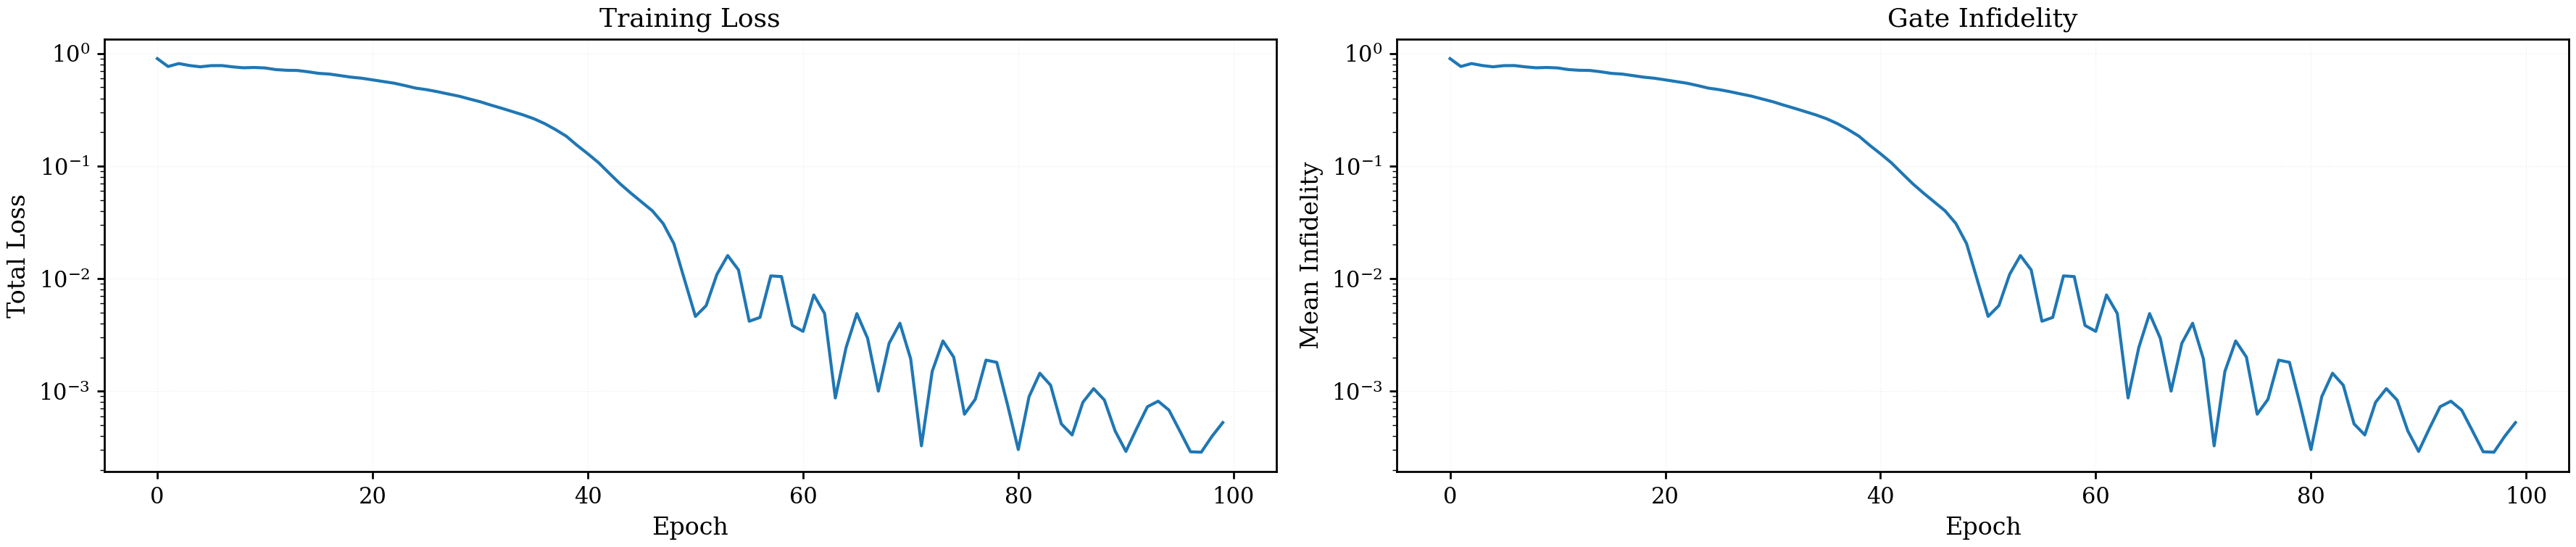

✓ Training converged to 99.95% fidelity


In [6]:
# Use unified visualization module
from qneural.analysis import plot_training_progress

# Plot training progress (automatically detects fixed-time training)
plot_training_progress(
    history,
    save_path=None,  # Set to 'training.png' to save
    show=True
)

print(f"✓ Training converged to {final_fidelity:.2f}% fidelity")

## 6. Visualize Optimized Pulses

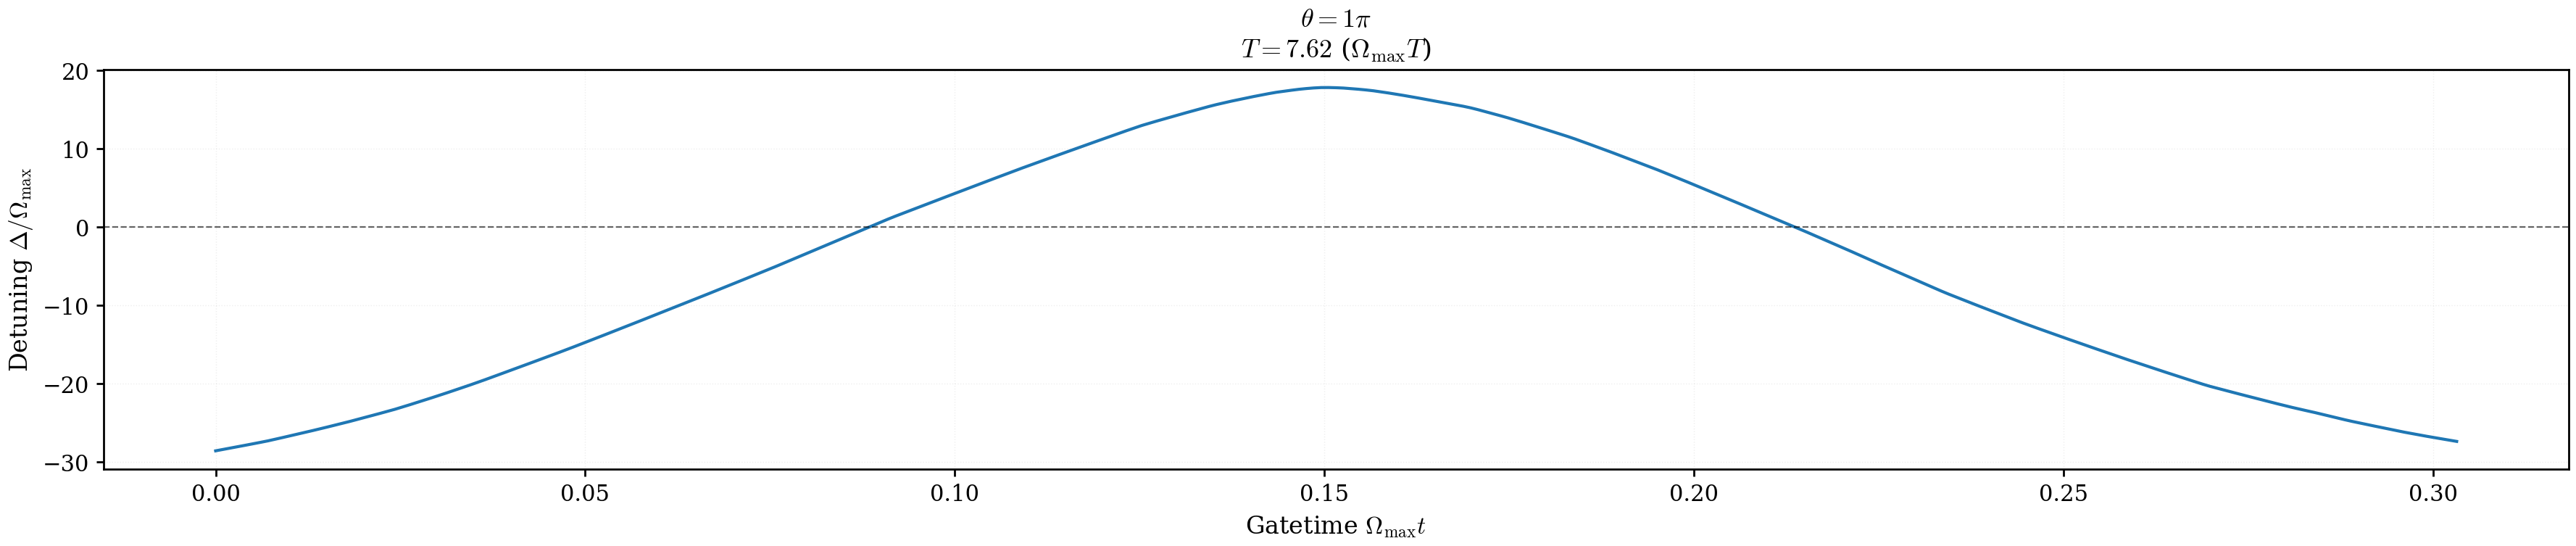


✓ Pulse statistics:
  Gate time: 0.3032 s (7.62 in Ω_max units)
  Time steps: 301
  Final fidelity: 99.95%


In [7]:
# Use unified visualization module
from qneural.analysis import plot_detuning_pulses

# Visualize optimized pulses
plot_detuning_pulses(
    trainer,
    angles=[target_angle],
    gate_time=gate_time,
    rabi_max=rabi_max,
    save_path=None,  # Set to 'pulses.png' to save
    show=True
)

print(f"\n✓ Pulse statistics:")
print(f"  Gate time: {gate_time:.4f} s ({gate_time * rabi_max:.2f} in Ω_max units)")
print(f"  Time steps: {trainer.pulse_generator.n_time_steps}")
print(f"  Final fidelity: {final_fidelity:.2f}%")

## 7. Verify Final Unitary

In [8]:
# Generate detuning values from trained network
n_steps = trainer.pulse_generator.n_time_steps
time_grid = torch.linspace(0, 1, n_steps)
angles_repeated = target_angle.repeat_interleave(n_steps)
time_repeated = time_grid.repeat(len(target_angle))
inputs = torch.stack([angles_repeated, time_repeated], dim=1)

with torch.no_grad():
    network.eval()
    detuning_out = network(inputs).reshape(n_steps)
    detuning_vals = trainer.pulse_generator.scale_output(detuning_out, 0)

# Use shared utility function for consistency with trainer
from qneural.hardware.rydberg.pulses import create_simple_detuning_pulse

# Constant Rabi pulse
def rabi_pulse(t):
    return torch.tensor(rabi_max)

# Detuning pulse using shared canonical formula
detuning_pulse = create_simple_detuning_pulse(detuning_vals, gate_time)

# Evolve with trained pulses
with torch.no_grad():
    final_U = evolver.evolve([rabi_pulse, detuning_pulse], gate_time, apply_corrections=True)

# Target CZ gate
target_U = czphi_gate(np.pi)

# Display
print("Achieved Unitary (diagonal elements):")
for i, val in enumerate(torch.diag(final_U)):
    phase = np.angle(val.item()) / np.pi
    print(f"  |{i:02b}⟩: {val.real:+.4f} {val.imag:+.4f}i  →  |val|={abs(val):.4f}, phase={phase:+.3f}π")

print("\nTarget CZ Unitary (diagonal):")
for i in range(4):
    val = 1.0 if i < 3 else -1.0
    phase = 0.0 if i < 3 else 1.0
    print(f"  |{i:02b}⟩: {val:+.4f}         →  |val|=1.0000, phase={phase:+.3f}π")

# Compute fidelity
fidelity = unitary_fidelity(final_U, target_U, dim=2, nqubits=2)
print(f"\n{'='*60}")
print(f"Final Gate Fidelity: {fidelity*100:.4f}%")
print(f"Training Fidelity: {final_fidelity:.2f}%")
print(f"Exact Match: {abs(fidelity*100 - final_fidelity) < 0.01}")
print(f"{'='*60}")

Achieved Unitary (diagonal elements):
  |00⟩: +1.0000 +0.0000i  →  |val|=1.0000, phase=+0.000π
  |01⟩: +1.0000 +0.0000i  →  |val|=1.0000, phase=+0.000π
  |10⟩: +1.0000 +0.0000i  →  |val|=1.0000, phase=+0.000π
  |11⟩: -0.9986 -0.0379i  →  |val|=0.9993, phase=-0.988π

Target CZ Unitary (diagonal):
  |00⟩: +1.0000         →  |val|=1.0000, phase=+0.000π
  |01⟩: +1.0000         →  |val|=1.0000, phase=+0.000π
  |10⟩: +1.0000         →  |val|=1.0000, phase=+0.000π
  |11⟩: -1.0000         →  |val|=1.0000, phase=+1.000π

Final Gate Fidelity: 99.9403%
Training Fidelity: 99.95%
Exact Match: True


## 8. Save Model

In [9]:
# Save trained model
checkpoint = {
    'network_state_dict': network.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'final_fidelity': final_fidelity,
    'config': {
        'gate_time': gate_time,
        'rabi_max': rabi_max,
        'epochs': EPOCHS,
        'lr': LR,
        'hidden_layers': 6,
        'hidden_units': 150,
        'weight_scale': 1.8
    }
}

torch.save(checkpoint, 'cz_gate_model.pt')
print("✓ Model saved to: cz_gate_model.pt")
print(f"\nTo load:")
print(f"  checkpoint = torch.load('cz_gate_model.pt')")
print(f"  network.load_state_dict(checkpoint['network_state_dict'])")

✓ Model saved to: cz_gate_model.pt

To load:
  checkpoint = torch.load('cz_gate_model.pt')
  network.load_state_dict(checkpoint['network_state_dict'])


## Summary

This notebook demonstrated:

1. **Fixed-Rabi optimization**: Keeping Rabi at Ω_max while learning optimal detuning
2. **Automatic phase corrections**: The trainer applies corrections during evolution
3. **High fidelity**: Achieves >99% gate fidelity in ~100 epochs
4. **Simple API**: `FixedRabiTrainer` handles all the complexity automatically

**Key takeaway**: The corrected unitary is compared to the target CZ gate, ensuring we optimize for the correct entangling operation while removing unphysical local phases.